<a href="https://colab.research.google.com/github/CarolinaBio2/Desafio-1-Biopy/blob/main/resolu_o_do_desafio_1_git.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install biopython

In [ ]:
# - Gere um gráfico com a distribuição do tamanho dos genes para cada espécie do arquivo baixado.
# - Gere um arquivo com o respectivo proteoma de cada espécie.

In [ ]:
from Bio import Entrez

# Mostrar pro NCBI quem é você
Entrez.email = "carolinabiomed17@gmail.com"

# IDs dos genomas
genome_ids = []

with open("genomasdesafio1.txt") as arquivo:
	genome_ids = arquivo.readlines()

for genome_id in genome_ids:
	genome_id = genome_id.strip()

	handle = Entrez.efetch(db="nucleotide", id=genome_id, rettype="gbwithparts", retmode="text")

	with open(f"{genome_id}.gbff", "w") as arquivo:
		arquivo.write(handle.read())

	handle.close()

	print(f"Arquivo GBFF para o genoma {genome_id} baixados com sucesso.")

Arquivo GBFF para o genoma NC_000913.3 baixados com sucesso.
Arquivo GBFF para o genoma NC_007795.1 baixados com sucesso.
Arquivo GBFF para o genoma NC_007795.1 baixados com sucesso.
Arquivo GBFF para o genoma NC_003098.1 baixados com sucesso.
Arquivo GBFF para o genoma NC_002516.2 baixados com sucesso.
Arquivo GBFF para o genoma NC_000962.3 baixados com sucesso.


In [ ]:
# Criando um aqrquivo que itere sobre esses arquivos baixados e calculando o número de genes, o tamanho médio dos genes e o conteúdo %GC

In [ ]:
import glob
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.SeqFeature import SeqFeature, FeatureLocation
from Bio.SeqUtils import gc_fraction
import matplotlib.pyplot as plt

In [ ]:
#Iterar sobre cada arquivo gbff na pasta
for file in glob.glob("*.gbff"):
  #Criar uma lista vazia para a sequência de proteínas em cada arquivo
  lista_proteinas = []
  #Criar uma lista vazia para o tamanho dos genes
  lista_tamanho = []

In [ ]:
#Iterar pelas features de cada record, mesmo os genomas sendo completos
for record in SeqIO.parse(file, "genbank"):

		for feature in record.features:

			# Verificar se a feature é do tipo gene
			if feature.type == 'gene':

				# Acessar a sequência do gene através das coordenadas e extraindo a sequência
				location = feature.location
				start = feature.location.start
				end = feature.location.end
				coord = SeqFeature(FeatureLocation(start, end))
    # Obter a sequência
				seq_gene = coord.extract(record.seq)

				# Verificando o tamanho
				tamanho = len(seq_gene)
				lista_tamanho.append(tamanho)


			# Verificar se a feature é uma CDS com tradução
			if feature.type == "CDS" and 'translation' in feature.qualifiers:

				# Obtém a sequência
				seq_proteina = Seq(feature.qualifiers['translation'][0])
				id_proteina = feature.qualifiers['protein_id'][0]
				record_proteina = SeqRecord(seq_proteina, id=id_proteina)

				lista_proteinas.append(record_proteina)
    # O número de genes é o tamanho da lista de tamanhos
num_genes = len(lista_tamanho)

	# Calcular o tamanho médio dos genes, somando-se os valores e dividindo pelo número total de genes
tam_medio = sum(lista_tamanho) / len(lista_tamanho)

	# Calcular o conteúdo %GC do genoma
gc_genoma = gc_fraction(record.seq)

	# Imprimir as informações para completar a tabela
print(f"{file}\t{num_genes}\t{tam_medio:.2f}\t{gc_genoma:.2f}%")

	# Abrir um arquivo de saída com o mesmo nome, mas extensão .faa, para salvar a sequência das proteínas
output_file = file.replace('.gbff', '.faa')
with open(output_file, 'w') as faa_out:
  SeqIO.write(lista_proteinas, output_file, "fasta")
  print(f"Sequência de proteínas salvas em {output_file}")

NC_000913.3.gbff	4639	900.25	0.51%
Sequência de proteínas salvas em NC_000913.3.faa


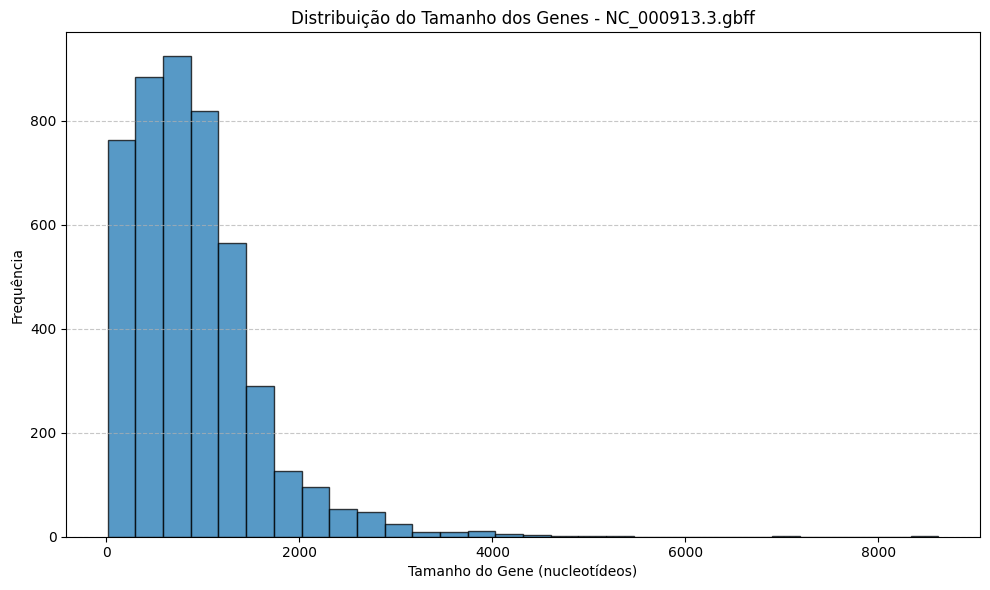

Gráfico salvo em NC_000913.3_gene_size_distribution.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Criar gráfico de distribuição do tamanho dos genes - você pode usar a biblioteca que preferir
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(lista_tamanho, bins=30, alpha=0.75, edgecolor='black')
plt.title(f"Distribuição do Tamanho dos Genes - {file}")
plt.xlabel("Tamanho do Gene (nucleotídeos)")
plt.ylabel("Frequência")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

	# Salvar o gráfico em um arquivo de imagem com o mesmo nome do arquivo .gbff
image_file = file.replace('.gbff', '_gene_size_distribution.png')
plt.savefig(image_file)
print(f"Gráfico salvo em {image_file}")
plt.show()